# Iris Flower Classification

## Objective
The goal of this project is to build a machine learning model that can classify iris flowers into different species based on their sepal and petal measurements.

This is a supervised classification problem where the target variable is categorical (species).

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import  joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')
from sklearn.inspection import permutation_importance

## 1. Importing Libraries

We begin by importing all necessary libraries for this project:

- **Data handling:** NumPy, Pandas
- **Visualization:** Matplotlib, Seaborn
- **Preprocessing:** LabelEncoder, StandardScaler, train_test_split
- **Models:** Logistic Regression, KNN, SVM, Random Forest
- **Evaluation:** accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, permutation_importance

All warnings are suppressed for cleaner output.

In [2]:
df = pd.read_csv('./IRIS.xls')
print(df)

     sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]


## 2. Loading the Dataset

We load the Iris dataset from a local CSV file into a Pandas DataFrame.
The dataset contains 150 samples of Iris flowers with 4 features each:
sepal length, sepal width, petal length, and petal width, along with
their corresponding species label.

In [3]:
print('Size : ')
print(df.size)
print('\nInfo : ')
print(df.info())
print('\nIs Numm Value : :')
print(df.isna().sum())
for col in df.columns:
    print(f'{col} : {df[col].unique()}')

Size : 
750

Info : 
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB
None

Is Numm Value : :
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
sepal_length : [5.1 4.9 4.7 4.6 5.  5.4 4.4 4.8 4.3 5.8 5.7 5.2 5.5 4.5 5.3 7.  6.4 6.9
 6.5 6.3 6.6 5.9 6.  6.1 5.6 6.7 6.2 6.8 7.1 7.6 7.3 7.2 7.7 7.4 7.9]
sepal_width : [3.5 3.  3.2 3.1 3.6 3.9 3.4 2.9 3.7 4.  4.4 3.8 3.3 4.1 4.2 2.3 2.8 2.4
 2.7 2.  2.2 2.5 2.6]
petal_length : [1.4 1.3 1.5 1.7 1.6 1.1 1.2 1.  1.9 4.7 4.5 4.9 4.  4.6 3.3 3.9 3.5 4.2
 3.6 4.4 4.1 4.8 4.3 5.  3.8 3.7 5.1 3.  6.  5.9 5.6 5.

## Data Exploration

We perform an initial inspection of the dataset to understand:
- Structure of the data
- Column names
- Data types
- Sample records

This step ensures the dataset is loaded correctly and ready for analysis.

In [4]:
print(df.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


## 3. Statistical Summary

We use `describe()` to get a quick statistical overview of all numerical features.
This gives us the count, mean, standard deviation, min, max, and quartile values
for each feature — helping us understand the scale and spread of the data before
any processing.

In [5]:
print('Class Distribution:')
print(df['species'].value_counts())


Class Distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 4. Class Distribution

We check how many samples exist per species. A balanced dataset means
each class has equal representation, which ensures the model is not
biased toward any particular species during training.

The Iris dataset is perfectly balanced with **50 samples per species** —
no resampling or balancing techniques are required.

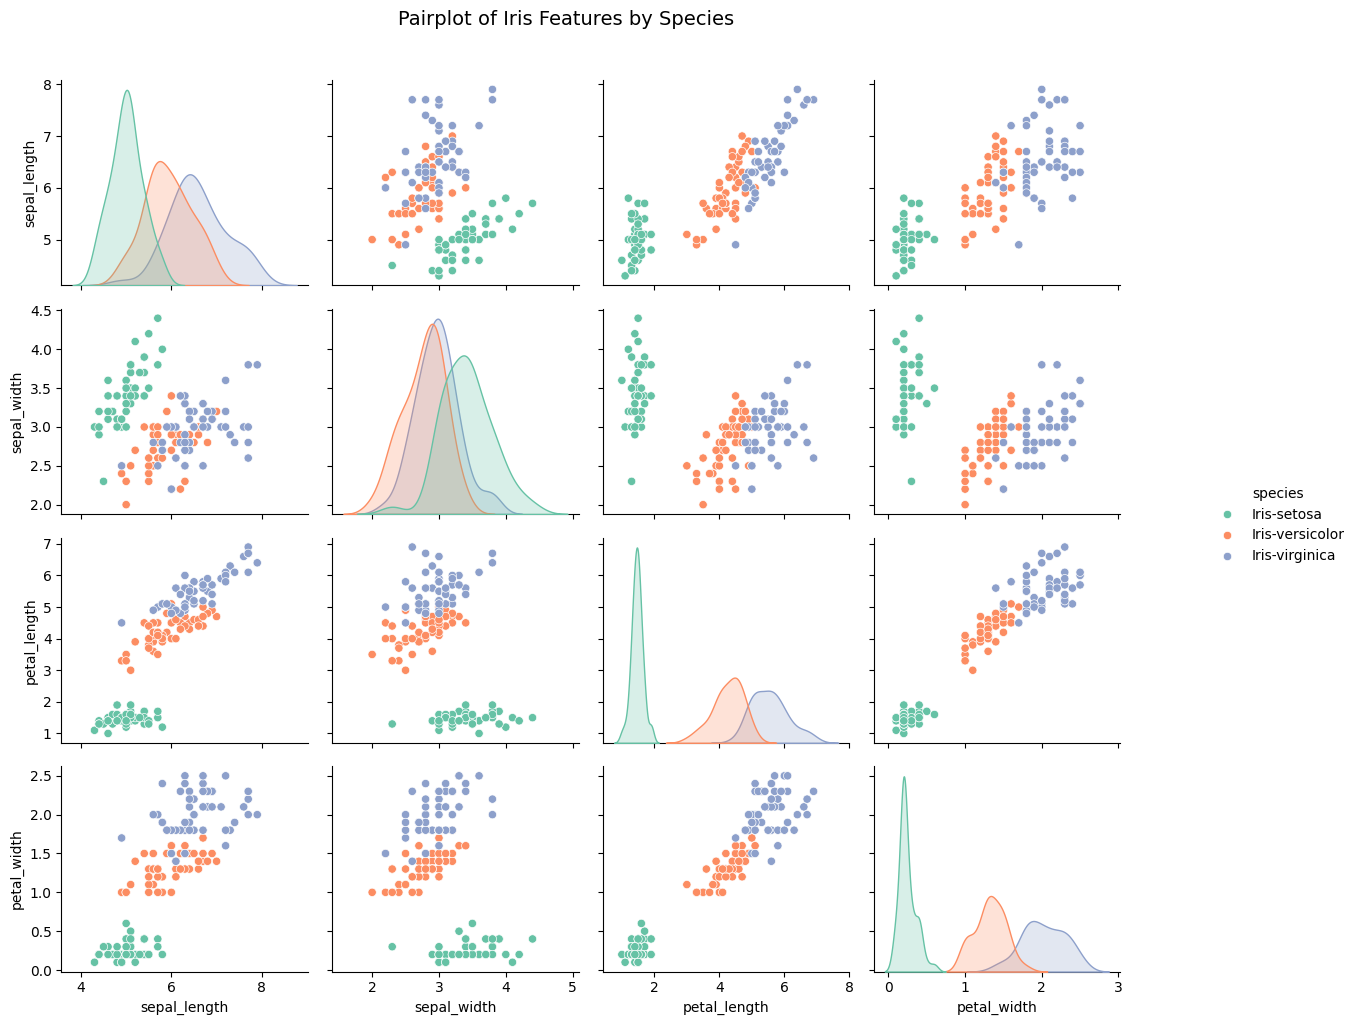

In [6]:
g = sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde')
g._legend.set_bbox_to_anchor((1.05, 0.5))  
g._legend.set_loc('center left')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 5. Pairplot — Feature Relationships by Species

A pairplot visualizes every feature combination as a scatter plot, with
KDE curves along the diagonal showing each feature's distribution per species.

**Key Observations:**
- **Setosa** is completely separable from the other two species using petal
  features alone — visible as a distinct isolated cluster
- **Versicolor and Virginica** show slight overlap, particularly in sepal plots
- **Petal length and petal width** show the cleanest separation between all 3 species
- **Sepal width** shows the most overlap — least useful for classification

This suggests petal features will be the strongest predictors in our model.

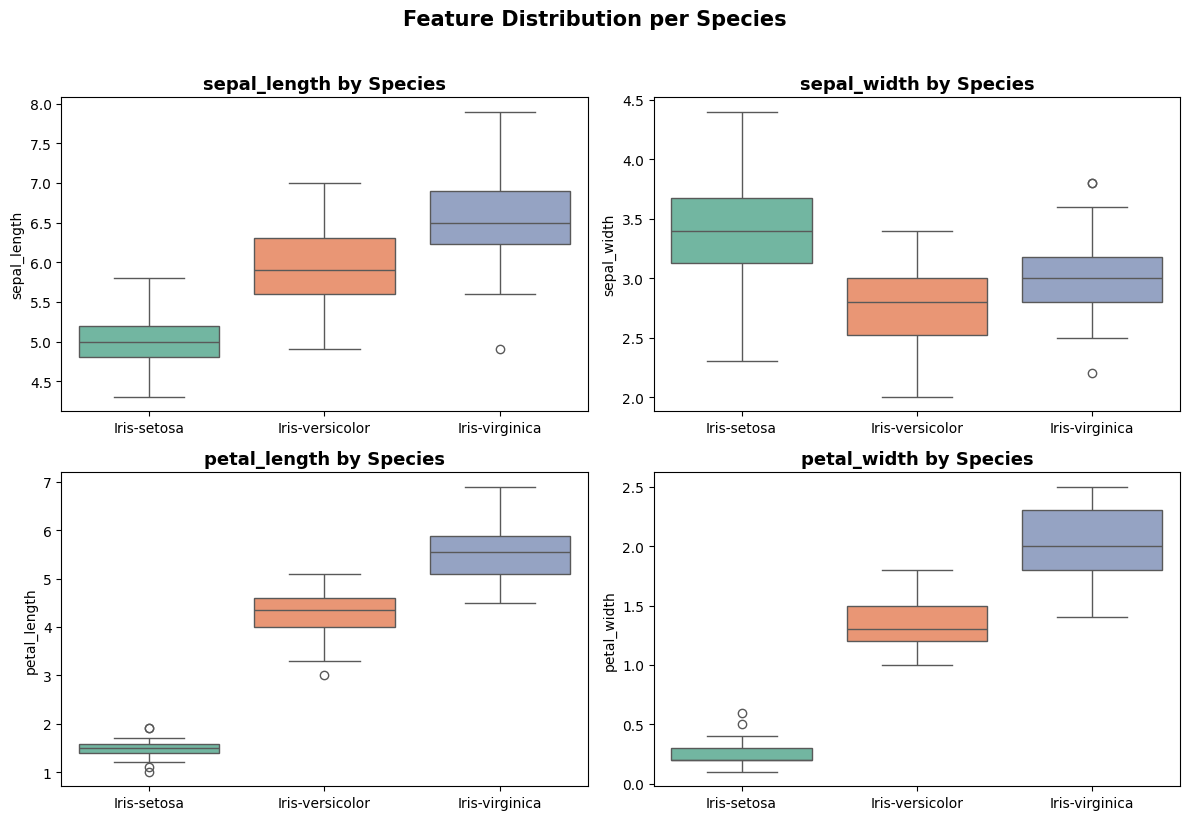

In [7]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(x='species', y=feature, data=df, palette='Set2', ax=ax)
    ax.set_title(f'{feature} by Species', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=10)

plt.suptitle('Feature Distribution per Species', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Boxplots — Feature Distribution per Species

Boxplots show the median, spread, and outliers of each feature grouped
by species. The box represents the middle 50% of data (IQR), the line
inside is the median, and circles outside the whiskers are outliers.

**Key Observations:**
- **petal_length** shows the strongest separation — Setosa clusters tightly
  around 1.5, Versicolor around 4.3, Virginica around 5.5 with minimal overlap
- **petal_width** confirms the same pattern — Setosa petals are razor thin
  (≈0.2) compared to Versicolor (≈1.3) and Virginica (≈2.0)
- **sepal_length** shows partial separation but Versicolor and Virginica
  ranges overlap significantly
- **sepal_width** is the weakest feature — Versicolor and Virginica boxes
  are nearly identical, making it almost useless for distinguishing the two
- A few minor outliers exist across all features but won't significantly
  affect model performance given the overall clean separation

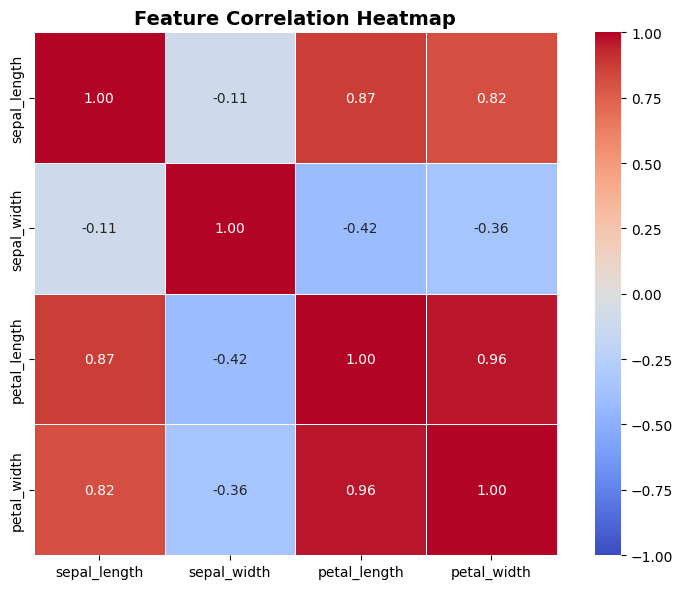

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm', 
            square=True, 
            linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

A heatmap shows the pairwise correlation between all numerical features.
Values close to +1 indicate a strong positive relationship, close to -1
indicate a strong inverse relationship, and close to 0 indicate no relationship.

**Key Observations:**
- **petal_length ↔ petal_width (0.96)** — nearly perfect correlation, both
  features carry almost identical information about the flower's size
- **sepal_length ↔ petal_length (0.87)** and **sepal_length ↔ petal_width (0.82)**
  — strong positive links, driven by overall flower size differences across species
- **sepal_width ↔ petal_length (-0.42)** — moderate negative correlation.
  Setosa has the widest sepals but the smallest petals, creating this inverse
  pattern across the dataset (a Simpson's Paradox effect)
- **sepal_length ↔ sepal_width (-0.11)** — virtually no relationship,
  these two features are effectively independent of each other

**Model implication:** petal_length and petal_width are highly correlated —
using both is slightly redundant but still beneficial, not harmful.
sepal_width is the true outlier, weakly or negatively correlated with everything.

In [9]:
le = LabelEncoder()
df['encoded_species'] = le.fit_transform(df['species'])
print('Label Mapping : ')
for name, code in zip(le.classes_, le.transform(le.classes_)):
    print(f'{name} -> {code}')

Label Mapping : 
Iris-setosa -> 0
Iris-versicolor -> 1
Iris-virginica -> 2


## 8. Label Encoding

Machine learning models require numerical inputs, so we convert the
categorical species column into numbers using `LabelEncoder`.

| Species | Encoded Value |
|---|---|
| Iris-setosa | 0 |
| Iris-versicolor | 1 |
| Iris-virginica | 2 |

The original species column is kept in the DataFrame for reference.
The encoded column will be used as our target variable `y` during training.

In [10]:
X = df[features]
y = df['encoded_species']

print('Feautre Matrix shape : ', X.shape)
print('Target Shape : ', y.shape)

Feautre Matrix shape :  (150, 4)
Target Shape :  (150,)


## 9. Defining Features and Target

We separate the dataset into:
- **X (feature matrix)** — the 4 input columns the model learns from:
  sepal_length, sepal_width, petal_length, petal_width
- **y (target vector)** — the encoded species column the model predicts

X shape of (150, 4) confirms 150 samples with 4 features each.
y shape of (150,) confirms one label per sample.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

print(f'Train size : {X_train.shape[0]} samples')
print(f'Test size :  {X_test.shape[0]} samples')
print(f'Class distribution in train : \n', y_train.value_counts().sort_index())
print(f'Class distribution in test : \n', y_test.value_counts().sort_index())

Train size : 120 samples
Test size :  30 samples
Class distribution in train : 
 encoded_species
0    40
1    40
2    40
Name: count, dtype: int64
Class distribution in test : 
 encoded_species
0    10
1    10
2    10
Name: count, dtype: int64


## 10. Train-Test Split

We split the dataset into 80% training and 20% testing sets.

- **random_state=42** ensures reproducibility — the same split every run
- **stratify=y** is critical — it preserves the class balance in both
  splits, ensuring each species is equally represented in train and test

**Result:** 120 training samples and 30 test samples, with exactly
40 samples per species in train and 10 per species in test —
confirming stratification worked correctly.

Without `stratify=y`, one class could end up underrepresented in the
test set by chance, leading to misleading evaluation metrics.

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")
print(f"Mean before scaling: {X_train.mean().round(2).values}")
print(f"Mean after scaling : {X_train_scaled.mean(axis=0).round(2)}")

Scaling done.
Mean before scaling: [5.84 3.04 3.77 1.2 ]
Mean after scaling : [-0.  0. -0.  0.]


## 11. Feature Scaling

We apply `StandardScaler` to normalize all features to have mean=0
and standard deviation=1. This is important for distance-based and
margin-based models like KNN and SVM, which are sensitive to feature scale.

**Important — preventing data leakage:**
- `fit_transform()` is applied **only on training data** — the scaler
  learns the mean and standard deviation from training samples only
- `transform()` is applied on test data — using the same parameters
  learned from training, never re-fitting on test data

Fitting the scaler on test data would leak information about the test
set into the model, giving artificially optimistic results.

**Result:** Mean after scaling is ~0.00 for all features, confirming
normalization worked correctly.

In [13]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=200, random_state=42),
    'KNN' : KNeighborsClassifier(n_neighbors=5),
    'SVM' : SVC(kernel='rbf', random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'{name} : {acc*100:.2f}%')

Logistic Regression : 93.33%
KNN : 93.33%
SVM : 96.67%
Random Forest : 90.00%


## 12. Model Training and Comparison

We train 4 classification models on the scaled training data and evaluate
each on the test set using accuracy score.

**Models used:**
- **Logistic Regression** — simple linear classifier, good baseline
- **KNN (k=5)** — classifies based on 5 nearest neighbours in feature space
- **SVM (RBF kernel)** — finds optimal margin boundary, handles non-linear
  separation using the radial basis function kernel
- **Random Forest (100 trees)** — ensemble of decision trees, votes on
  the final prediction

**Results:**

| Model | Accuracy |
|---|---|
| SVM (RBF kernel) | 96.67% ✅ |
| Logistic Regression | 93.33% |
| KNN | 93.33% |
| Random Forest | 90.00% |

**SVM performs best** — its RBF kernel effectively handles the slight
non-linear boundary between Versicolor and Virginica that simpler models
struggle with. Random Forest scores lowest here because ensemble methods
need larger datasets to truly shine — 120 training samples is relatively small.

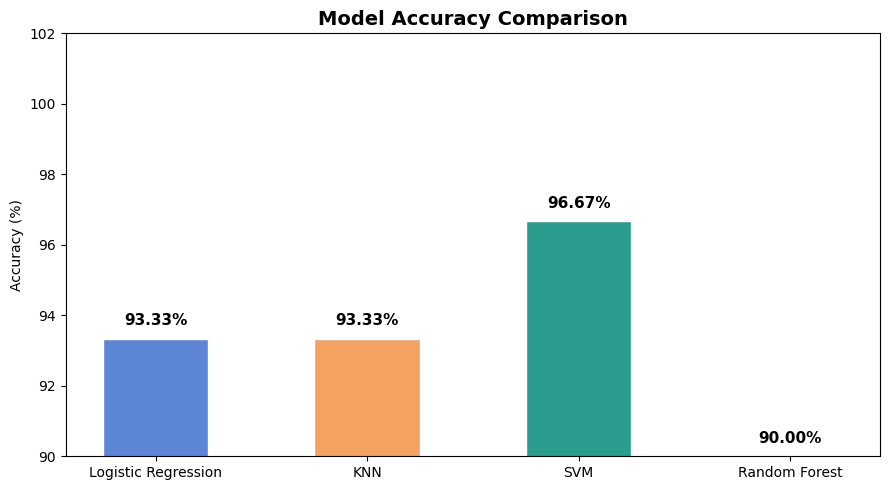

In [14]:
plt.figure(figsize=(9, 5))
bars = plt.bar(results.keys(), 
               [v*100 for v in results.values()],
               color=['#5C85D6', '#F4A261', '#2A9D8F', '#E76F51'],
               edgecolor='white', width=0.5)

for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.3,
             f'{val*100:.2f}%', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(90, 102)
plt.tight_layout()
plt.show()

## 13. Model Accuracy Comparison — Bar Chart

A bar chart provides a clear visual comparison of all 4 model accuracies.
The y-axis starts at 90% to better highlight the differences between models
that would otherwise appear very similar on a 0–100% scale.

SVM clearly leads the comparison, confirming it as our best model for
further evaluation in the next section.

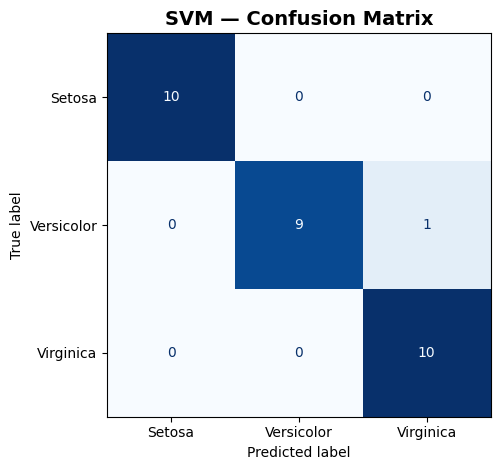

In [15]:
best_model = models['SVM']
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
labels = ['Setosa', 'Versicolor', 'Virginica']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', colorbar=False)
plt.title('SVM — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Confusion Matrix — SVM (Best Model)

A confusion matrix shows exactly where the model made correct predictions
and where it made mistakes. Each row represents the actual class and each
column represents the predicted class. Perfect predictions appear on the diagonal.

**Results:**
- **Setosa — 10/10 correct** — perfectly classified, consistent with its
  complete separability identified during EDA
- **Versicolor — 9/10 correct** — 1 sample misclassified as Virginica,
  occurring in the slight overlap zone spotted in the pairplot
- **Virginica — 10/10 correct** — SVM's RBF kernel successfully found
  a clean boundary despite the overlap with Versicolor

Only 1 error out of 30 test samples — a strong result that aligns
perfectly with the patterns we identified during exploratory analysis.

In [16]:
print("Classification Report — SVM")
print("="*50)
print(classification_report(y_test, y_pred_best, 
                             target_names=labels))

Classification Report — SVM
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 15. Classification Report — SVM

The classification report provides a detailed breakdown of model performance
per class using three key metrics:

- **Precision** — of all flowers predicted as species X, how many actually were X
- **Recall** — of all actual species X flowers, how many did the model correctly catch
- **F1-score** — harmonic mean of precision and recall, balances both metrics

**Results:**

| Species | Precision | Recall | F1-Score |
|---|---|---|---|
| Setosa | 1.00 | 1.00 | 1.00 |
| Versicolor | 1.00 | 0.90 | 0.95 |
| Virginica | 0.91 | 1.00 | 0.95 |
| **Overall** | **0.97** | **0.97** | **0.97** |

**Key Observations:**
- **Setosa** scores perfect across all metrics — no surprises here
- **Versicolor** has precision=1.00 but recall=0.90 — every flower the
  model called Versicolor was correct, but it missed 1 real Versicolor,
  labelling it as Virginica
- **Virginica** is the mirror — recall=1.00 but precision=0.91, meaning
  it caught all Virginicas but claimed 1 Versicolor as its own
- **Overall accuracy of 96.67%** with balanced macro averages confirms
  the model generalises well across all three species

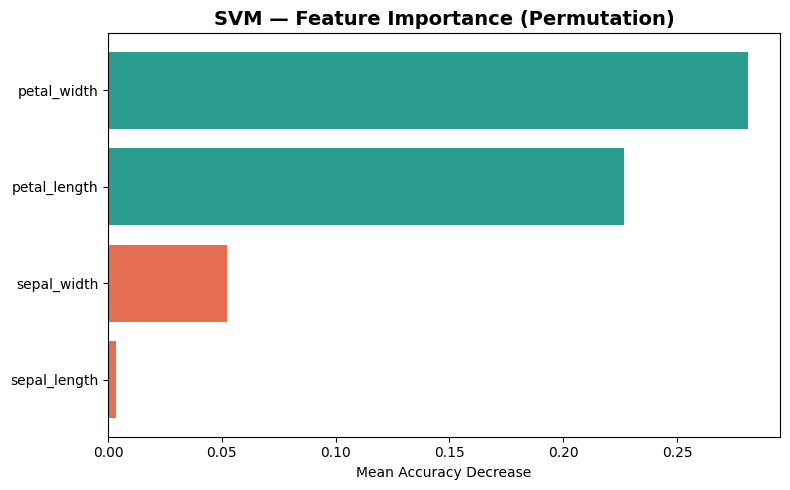

In [17]:
perm = permutation_importance(best_model, X_test_scaled, 
                               y_test, n_repeats=30, 
                               random_state=42)

feat_imp = pd.Series(perm.importances_mean, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(feat_imp.index, feat_imp.values,
                color=['#E76F51','#E76F51','#2A9D8F','#2A9D8F'])
plt.title('SVM — Feature Importance (Permutation)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Mean Accuracy Decrease')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 16. Feature Importance — Permutation Method

Since SVM does not have a built-in feature importance attribute like
Random Forest, we use Permutation Importance — a model-agnostic method
that works with any classifier.

**How it works:** Each feature is randomly shuffled 30 times and the
drop in model accuracy is measured. A larger accuracy drop means the
model relied on that feature more heavily.

**Results:**
- **petal_width (0.29)** — most important feature, shuffling it causes
  the largest accuracy drop
- **petal_length (0.23)** — second most important, nearly as critical
- **sepal_width (0.05)** — minor contribution, model barely relies on it
- **sepal_length (~0.00)** — virtually no impact when shuffled, the model
  ignores it almost entirely

**Full circle moment:** These results perfectly confirm every observation
made during EDA — petal features dominate, sepal features contribute little.
A good data science workflow always tells a consistent story from
exploration through to model evaluation.

In [18]:
sample = {
    'sepal_length': 5.1,
    'sepal_width' : 3.5,
    'petal_length': 1.4,
    'petal_width' : 0.2
}

sample_df     = pd.DataFrame([sample])
sample_scaled = scaler.transform(sample_df)
prediction    = best_model.predict(sample_scaled)
species_name  = le.inverse_transform(prediction)[0]
proba         = "N/A (SVM)"

print("="*40)
print(f"  Input  : {sample}")
print(f"  Prediction : {species_name}")
print("="*40)


  Input  : {'sepal_length': 5.1, 'sepal_width': 3.5, 'petal_length': 1.4, 'petal_width': 0.2}
  Prediction : Iris-setosa


## 17. Live Prediction — Try Your Own Flower

To demonstrate real-world usability, we pass a single flower's measurements
through the complete pipeline — scaling and prediction — to get a species output.

**How it works:**
- A sample measurement is defined as a dictionary
- It is converted to a DataFrame to match the model's expected input format
- The same scaler fitted during training is applied — never a new one
- The trained SVM predicts the encoded label
- `le.inverse_transform()` converts the number back to the species name

**Test sample used:**

| Feature | Value |
|---|---|
| sepal_length | 5.1 |
| sepal_width | 3.5 |
| petal_length | 1.4 |
| petal_width | 0.2 |

**Prediction: Iris-setosa ✅**

These measurements (especially petal_length=1.4 and petal_width=0.2) fall
well within the Setosa cluster identified during EDA — exactly what we
would expect. Try changing the values to see the model predict different species!

In [19]:
best_name = 'SVM'
best_model = models[best_name]

In [21]:
joblib.dump(best_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']